# Intelligent Log Anomaly Detection System
### End-to-End Pipeline Notebook

In [5]:
!pip install drain3
import os
os.makedirs('data/raw', exist_ok=True)

from google.colab import files
uploaded = files.upload()

import shutil
shutil.move('HDFS_sample.log', 'data/raw/HDFS_sample.log')

uploaded = files.upload()
shutil.move('anomaly_label.csv', 'data/raw/anomaly_label.csv')

Saving HDFS_sample.log to HDFS_sample.log


Saving anomaly_label.csv to anomaly_label.csv


'data/raw/anomaly_label.csv'

In [6]:
import os
import re
import ast
import sys
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.sparse import save_npz, load_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s'
)
logger = logging.getLogger(__name__)

LOG_PATH        = 'data/raw/HDFS_sample.log'
LABEL_PATH      = 'data/raw/anomaly_label.csv'
PARSED_PATH     = 'data/processed/parsed_logs.csv'
SEQUENCES_PATH  = 'data/processed/sequences.csv'
MATRIX_PATH     = 'data/processed/tfidf_matrix.npz'
LABELS_PATH     = 'data/processed/labels.npy'
VECTORIZER_PATH = 'data/processed/tfidf_vectorizer.joblib'
SCALER_PATH     = 'data/processed/scaler.joblib'
IF_MODEL_PATH   = 'data/processed/isolation_forest.joblib'
SVM_MODEL_PATH  = 'data/processed/one_class_svm.joblib'
PREDS_PATH      = 'data/processed/predictions.csv'
PLOTS_DIR       = 'outputs/plots/'
RESULTS_DIR     = 'outputs/results/'

os.makedirs('data/processed', exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete')

Setup complete


## 1. Ingestion

In [7]:
MIN_FIELDS = 5

def load_raw_logs(log_path):
    if not os.path.exists(log_path):
        raise FileNotFoundError(f'Log file not found: {log_path}')
    raw_lines = []
    skipped = 0
    total = 0
    logger.info(f'Loading raw logs from: {log_path}')
    with open(log_path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            total += 1
            line = line.strip()
            if not line or len(line.split()) < MIN_FIELDS:
                skipped += 1
                continue
            raw_lines.append(line)
    logger.info(f'Total lines read     : {total}')
    logger.info(f'Valid lines kept     : {len(raw_lines)}')
    logger.info(f'Lines skipped        : {skipped}')
    return raw_lines


def load_labels(label_path):
    if not os.path.exists(label_path):
        raise FileNotFoundError(f'Label file not found: {label_path}')
    logger.info(f'Loading labels from: {label_path}')
    df = pd.read_csv(label_path)
    df.columns = [c.strip() for c in df.columns]
    label_map = {
        row['BlockId']: 1 if row['Label'].strip() == 'Anomaly' else 0
        for _, row in df.iterrows()
    }
    total_blocks = len(label_map)
    anomalous = sum(label_map.values())
    normal = total_blocks - anomalous
    logger.info(f'Total blocks         : {total_blocks}')
    logger.info(f'Normal blocks        : {normal}')
    logger.info(f'Anomalous blocks     : {anomalous}')
    logger.info(f'Anomaly rate         : {anomalous / total_blocks * 100:.2f}%')
    return label_map


raw_lines = load_raw_logs(LOG_PATH)
label_map = load_labels(LABEL_PATH)

print('\n--- First 3 raw log lines ---')
for line in raw_lines[:3]:
    print(line)

print('\n--- First 3 label entries ---')
for block_id, label in list(label_map.items())[:3]:
    print(f'{block_id} -> {label}')


--- First 3 raw log lines ---
081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906
081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010

--- First 3 label entries ---
blk_-1608999687919862906 -> 0
blk_7503483334202473044 -> 0
blk_-3544583377289625738 -> 1


## 2. Parsing and Template Extraction

In [8]:
LOG_PATTERN = re.compile(
    r'^(\d{6})\s+'
    r'(\d{6})\s+'
    r'(\d+)\s+'
    r'(\w+)\s+'
    r'([\w.$]+):\s+'
    r'(.+)$'
)
BLOCK_PATTERN = re.compile(r'(blk_-?\d+)')
RE_BLOCK      = re.compile(r'blk_-?\d+')
RE_IP         = re.compile(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}(:\d+)?')
RE_NUMBER     = re.compile(r'\b\d+\b')


def clean_content(content):
    content = RE_BLOCK.sub('<BLOCK>', content)
    content = RE_IP.sub('<IP>', content)
    content = RE_NUMBER.sub('<NUM>', content)
    return content


def build_drain3_miner():
    config = TemplateMinerConfig()
    config.drain_sim_th      = 0.5
    config.drain_depth       = 4
    config.profiling_enabled = False
    return TemplateMiner(config=config)


def parse_logs(raw_lines):
    miner     = build_drain3_miner()
    records   = []
    malformed = 0
    logger.info(f'Parsing {len(raw_lines):,} log lines with Drain3...')
    for i, line in enumerate(raw_lines):
        match = LOG_PATTERN.match(line)
        if not match:
            malformed += 1
            continue
        date, time, pid, level, component, content = match.groups()
        block_ids = BLOCK_PATTERN.findall(content)
        cleaned   = clean_content(content)
        miner.add_log_message(cleaned)
        records.append({
            'date'      : date,
            'time'      : time,
            'pid'       : int(pid),
            'level'     : level,
            'component' : component,
            'content'   : content,
            'block_ids' : block_ids,
        })
        if (i + 1) % 1_000_000 == 0:
            logger.info(f'  Processed {i + 1:,} lines...')
    logger.info(f'Parsing complete')
    logger.info(f'Records parsed       : {len(records):,}')
    logger.info(f'Malformed lines      : {malformed:,}')
    logger.info(f'Unique templates     : {len(miner.drain.id_to_cluster):,}')
    df = pd.DataFrame(records)
    logger.info('Remapping templates using final cluster state...')
    final_templates = []
    for content in df['content']:
        cleaned = clean_content(content)
        result  = miner.match(cleaned)
        if result:
            final_templates.append(result.get_template())
        else:
            final_templates.append(cleaned)
    df['template'] = final_templates
    logger.info('Remapping complete')
    return df


df = parse_logs(raw_lines)
df.to_csv(PARSED_PATH, index=False)

print('\n--- Shape ---')
print(df.shape)

print('\n--- Sample row ---')
print(df.iloc[0])

print('\n--- Unique templates ---')
templates = df['template'].unique()
print(f'Total unique templates: {len(templates)}')
for t in templates[:15]:
    print(t)


--- Shape ---
(50000, 8)

--- Sample row ---
date                                                    081109
time                                                    203518
pid                                                        143
level                                                     INFO
component                             dfs.DataNode$DataXceiver
content      Receiving block blk_-1608999687919862906 src: ...
block_ids                           [blk_-1608999687919862906]
template        Receiving block <BLOCK> src: /<IP> dest: /<IP>
Name: 0, dtype: object

--- Unique templates ---
Total unique templates: 16
Receiving block <BLOCK> src: /<IP> dest: /<IP>
BLOCK* NameSystem.allocateBlock: <*> <BLOCK>
PacketResponder <NUM> for block <BLOCK> terminating
Received block <BLOCK> of size <NUM> from /<IP>
BLOCK* NameSystem.addStoredBlock: blockMap updated: <IP> is added to <BLOCK> size <NUM>
Received block <BLOCK> src: /<IP> dest: /<IP> of size <NUM>
<IP>:Transmitted block <BLOCK> to 

## 3. Sequence Construction

In [9]:
def build_sequences(df, label_map):
    logger.info('Exploding block_ids to individual rows...')
    df['block_ids'] = df['block_ids'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    df = df[df['block_ids'].apply(lambda x: len(x) > 0)].copy()
    df = df.explode('block_ids').rename(columns={'block_ids': 'block_id'})
    logger.info('Grouping by block_id to build sequences...')
    sequences = (
        df.groupby('block_id')['template']
        .apply(list)
        .reset_index()
    )
    sequences.columns = ['block_id', 'event_sequence']
    sequences['sequence_str'] = sequences['event_sequence'].apply(
        lambda events: ' '.join(events)
    )
    sequences['label'] = sequences['block_id'].map(label_map)
    before = len(sequences)
    sequences = sequences.dropna(subset=['label'])
    sequences['label'] = sequences['label'].astype(int)
    after = len(sequences)
    logger.info(f'Blocks before label join : {before:,}')
    logger.info(f'Blocks after label join  : {after:,}')
    logger.info(f'Blocks dropped (no label): {before - after:,}')
    normal    = (sequences['label'] == 0).sum()
    anomalous = (sequences['label'] == 1).sum()
    total     = len(sequences)
    logger.info(f'Total sequences  : {total:,}')
    logger.info(f'Normal           : {normal:,}  ({normal/total*100:.2f}%)')
    logger.info(f'Anomalous        : {anomalous:,}  ({anomalous/total*100:.2f}%)')
    return sequences


sequences = build_sequences(df, label_map)
sequences.to_csv(SEQUENCES_PATH, index=False)

print('\n--- Shape ---')
print(sequences.shape)

print('\n--- Label distribution ---')
print(sequences['label'].value_counts())


--- Shape ---
(4087, 4)

--- Label distribution ---
label
0    3964
1     123
Name: count, dtype: int64


## 4. Exploratory Data Analysis

In [10]:
# 4.1 Overview
print(f'Total log lines      : {len(df):,}')
print(f'Total sequences      : {len(sequences):,}')
print(f'Normal sequences     : {(sequences["label"] == 0).sum():,}')
print(f'Anomalous sequences  : {(sequences["label"] == 1).sum():,}')
print(f'Anomaly rate         : {sequences["label"].mean() * 100:.2f}%')
print(f'Unique templates     : {df["template"].nunique()}')
print(f'Unique components    : {df["component"].nunique()}')

Total log lines      : 50,000
Total sequences      : 4,087
Normal sequences     : 3,964
Anomalous sequences  : 123
Anomaly rate         : 3.01%
Unique templates     : 16
Unique components    : 6


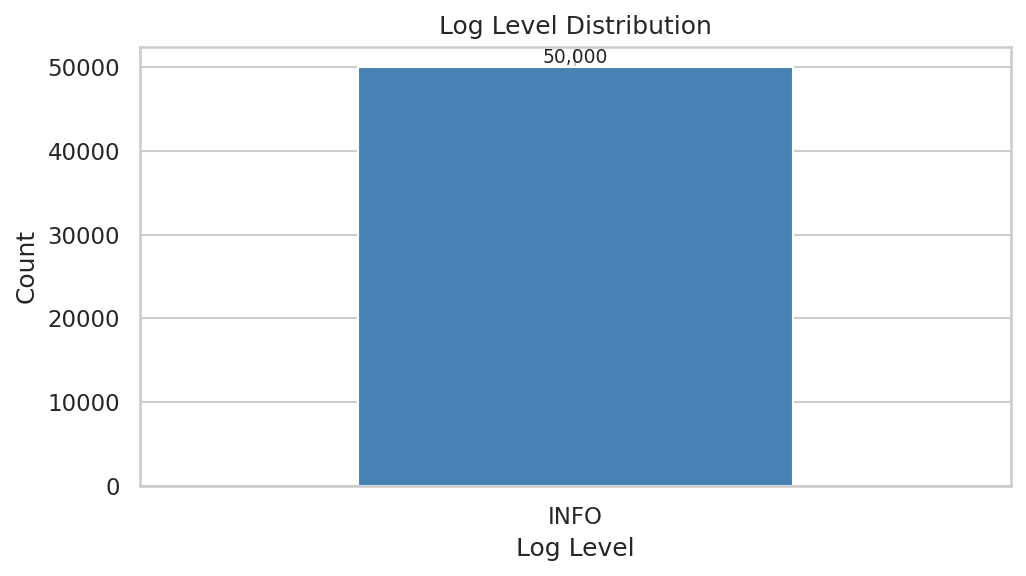

In [11]:
# 4.2 Log level distribution
level_counts = df['level'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
level_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Log Level Distribution')
ax.set_xlabel('Log Level')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=9
    )
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}eda_log_levels.png')
plt.show()

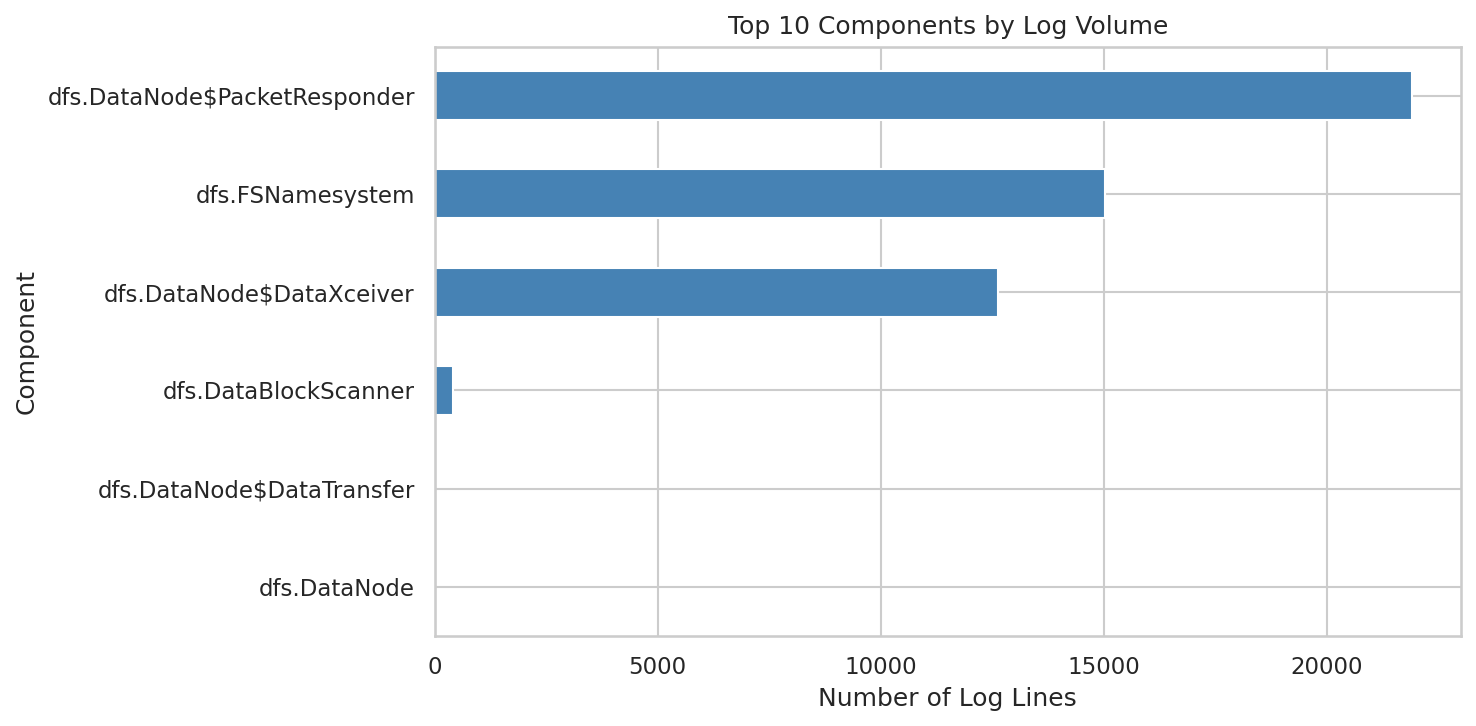

In [12]:
# 4.3 Top components
top_components = df['component'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_components.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Components by Log Volume')
ax.set_xlabel('Number of Log Lines')
ax.set_ylabel('Component')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}eda_top_components.png')
plt.show()

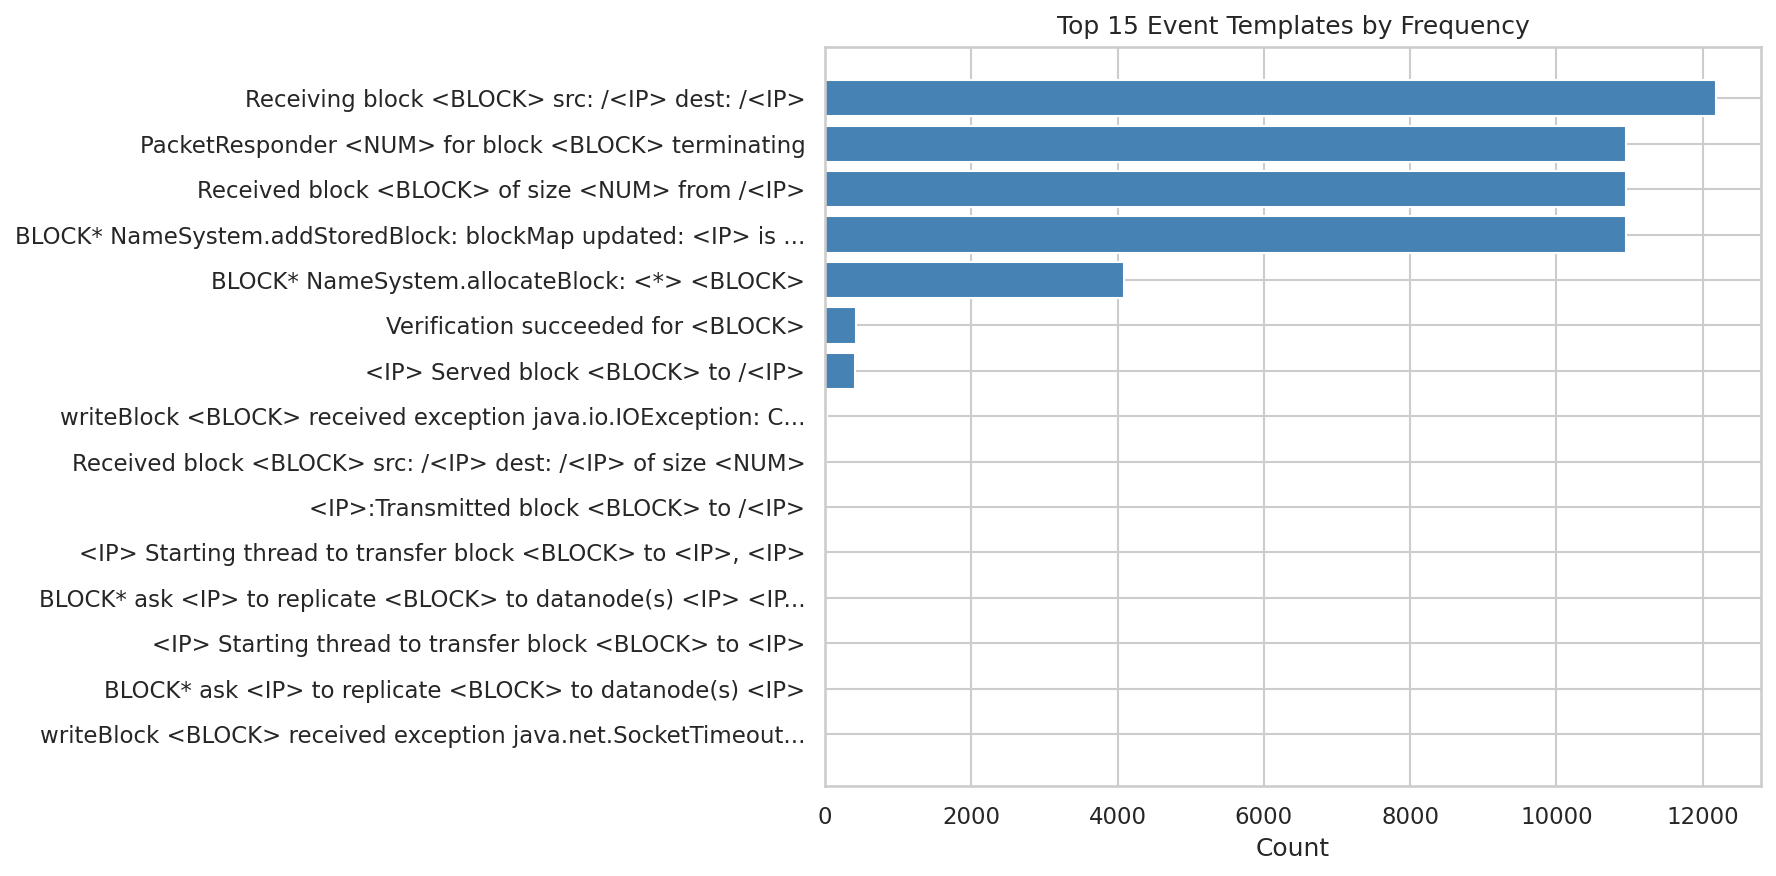

In [13]:
# 4.4 Template frequency
top_templates = df['template'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
labels = [t[:60] + '...' if len(t) > 60 else t for t in top_templates.index]
ax.barh(labels, top_templates.values, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Event Templates by Frequency')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}eda_template_frequency.png')
plt.show()

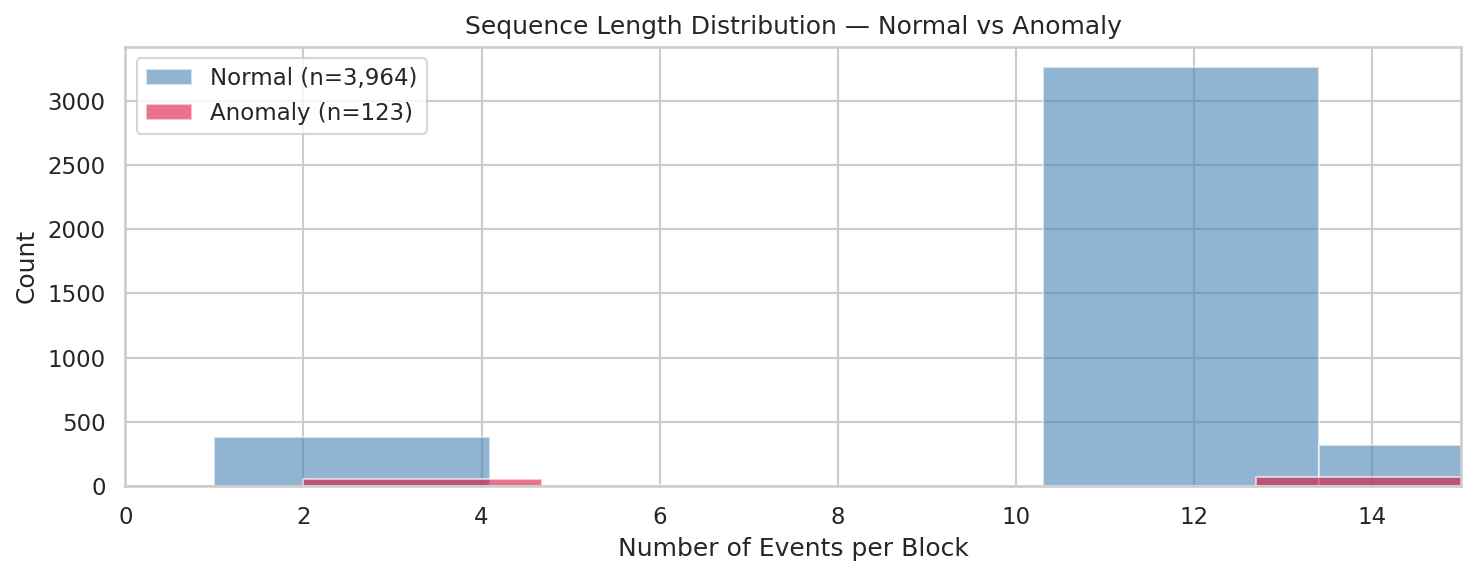

In [14]:
# 4.5 Sequence length by label
sequences['seq_length'] = sequences['event_sequence'].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else len(x)
)
normal_lengths  = sequences.loc[sequences['label'] == 0, 'seq_length']
anomaly_lengths = sequences.loc[sequences['label'] == 1, 'seq_length']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_lengths,  bins=80, alpha=0.6, label=f'Normal (n={len(normal_lengths):,})',  color='steelblue')
ax.hist(anomaly_lengths, bins=80, alpha=0.6, label=f'Anomaly (n={len(anomaly_lengths):,})', color='crimson')
ax.set_title('Sequence Length Distribution — Normal vs Anomaly')
ax.set_xlabel('Number of Events per Block')
ax.set_ylabel('Count')
ax.set_xlim(0, sequences['seq_length'].quantile(0.99))
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}eda_sequence_lengths_by_label.png')
plt.show()

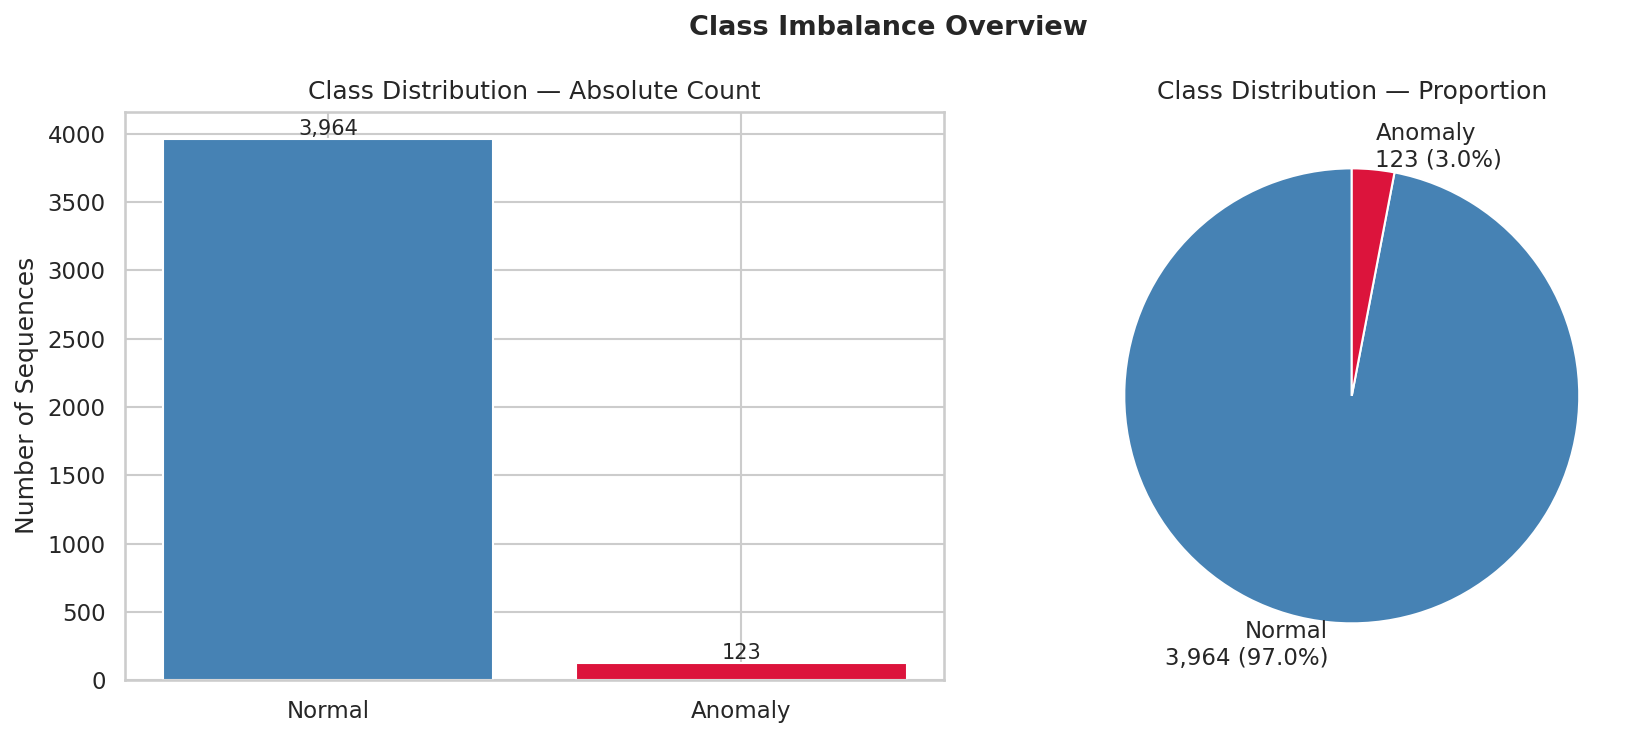

In [15]:
# 4.6 Class imbalance
label_counts = sequences['label'].value_counts().sort_index()
labels_list  = ['Normal', 'Anomaly']
colors       = ['steelblue', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(labels_list, label_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution — Absolute Count')
axes[0].set_ylabel('Number of Sequences')
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].annotate(
        f'{val:,}',
        (bar.get_x() + bar.get_width() / 2, val),
        ha='center', va='bottom', fontsize=10
    )
axes[1].pie(
    label_counts.values,
    labels=[f'{l}\n{v:,} ({v/len(sequences)*100:.1f}%)'
            for l, v in zip(labels_list, label_counts.values)],
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Class Distribution — Proportion')
plt.suptitle('Class Imbalance Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}eda_class_imbalance.png')
plt.show()

## 5. Feature Engineering

In [16]:
vectorizer = TfidfVectorizer(
    max_features=100,
    lowercase=False,
    token_pattern=r'\S+'
)
X = vectorizer.fit_transform(sequences['sequence_str'])
y = sequences['label'].values

scaler   = MaxAbsScaler()
X_scaled = scaler.fit_transform(X)

save_npz(MATRIX_PATH, X)
np.save(LABELS_PATH, y)
joblib.dump(vectorizer, VECTORIZER_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f'Feature matrix shape : {X.shape}')
print(f'Density              : {X.nnz / (X.shape[0] * X.shape[1]) * 100:.2f}%')

Feature matrix shape : (4087, 46)
Density              : 49.16%


## 6. Model Training

In [17]:
# Isolation Forest
if_model = IsolationForest(
    n_estimators=100,
    contamination=0.0293,
    random_state=42,
    n_jobs=-1
)
if_model.fit(X_scaled)
if_scores = if_model.decision_function(X_scaled)
if_preds  = np.where(if_model.predict(X_scaled) == -1, 1, 0)
joblib.dump(if_model, IF_MODEL_PATH)

print(f'Isolation Forest anomalies detected : {if_preds.sum():,}')
print(f'Score range : {if_scores.min():.4f} to {if_scores.max():.4f}')

Isolation Forest anomalies detected : 65
Score range : -0.1026 to 0.2786


In [21]:
# One-Class SVM (subsampled for scalability)
rng     = np.random.RandomState(42)
n_train = min(50_000, X_scaled.shape[0])
idx     = rng.choice(X_scaled.shape[0], size=n_train, replace=False)
X_train = X_scaled[idx]

svm_model = OneClassSVM(kernel='rbf', nu=0.0293, gamma='scale')
svm_model.fit(X_train.toarray())

svm_scores = svm_model.decision_function(X_scaled.toarray())
svm_preds  = np.where(svm_model.predict(X_scaled.toarray()) == -1, 1, 0)
joblib.dump(svm_model, SVM_MODEL_PATH)

print(f'One-Class SVM anomalies detected : {svm_preds.sum():,}')
print(f'Score range : {svm_scores.min():.4f} to {svm_scores.max():.4f}')

One-Class SVM anomalies detected : 3,766
Score range : -43.3836 to 8.0497


In [22]:
# Save predictions
sequences['if_pred']   = if_preds
sequences['if_score']  = if_scores
sequences['svm_pred']  = svm_preds
sequences['svm_score'] = svm_scores
sequences.to_csv(PREDS_PATH, index=False)

print(f'Actual anomalies         : {y.sum():,}')
print(f'Isolation Forest flagged : {if_preds.sum():,}')
print(f'One-Class SVM flagged    : {svm_preds.sum():,}')

Actual anomalies         : 123
Isolation Forest flagged : 65
One-Class SVM flagged    : 3,766


## 7. Evaluation

In [23]:
def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    print(f'\n--- {model_name} ---')
    print(f'Precision : {precision:.4f}')
    print(f'Recall    : {recall:.4f}')
    print(f'F1 Score  : {f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))
    return {'model': model_name, 'precision': precision, 'recall': recall, 'f1': f1}


if_results  = evaluate_model(y, if_preds,  'Isolation Forest')
svm_results = evaluate_model(y, svm_preds, 'One-Class SVM')

results_df = pd.DataFrame([if_results, svm_results])
results_df.to_csv(f'{RESULTS_DIR}evaluation_results.csv', index=False)
print(results_df.to_string(index=False))


--- Isolation Forest ---
Precision : 0.6308
Recall    : 0.3333
F1 Score  : 0.4362
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99      3964
     Anomaly       0.63      0.33      0.44       123

    accuracy                           0.97      4087
   macro avg       0.81      0.66      0.71      4087
weighted avg       0.97      0.97      0.97      4087


--- One-Class SVM ---
Precision : 0.0316
Recall    : 0.9675
F1 Score  : 0.0612
              precision    recall  f1-score   support

      Normal       0.99      0.08      0.15      3964
     Anomaly       0.03      0.97      0.06       123

    accuracy                           0.11      4087
   macro avg       0.51      0.52      0.10      4087
weighted avg       0.96      0.11      0.15      4087

           model  precision   recall       f1
Isolation Forest   0.630769 0.333333 0.436170
   One-Class SVM   0.031599 0.967480 0.061198


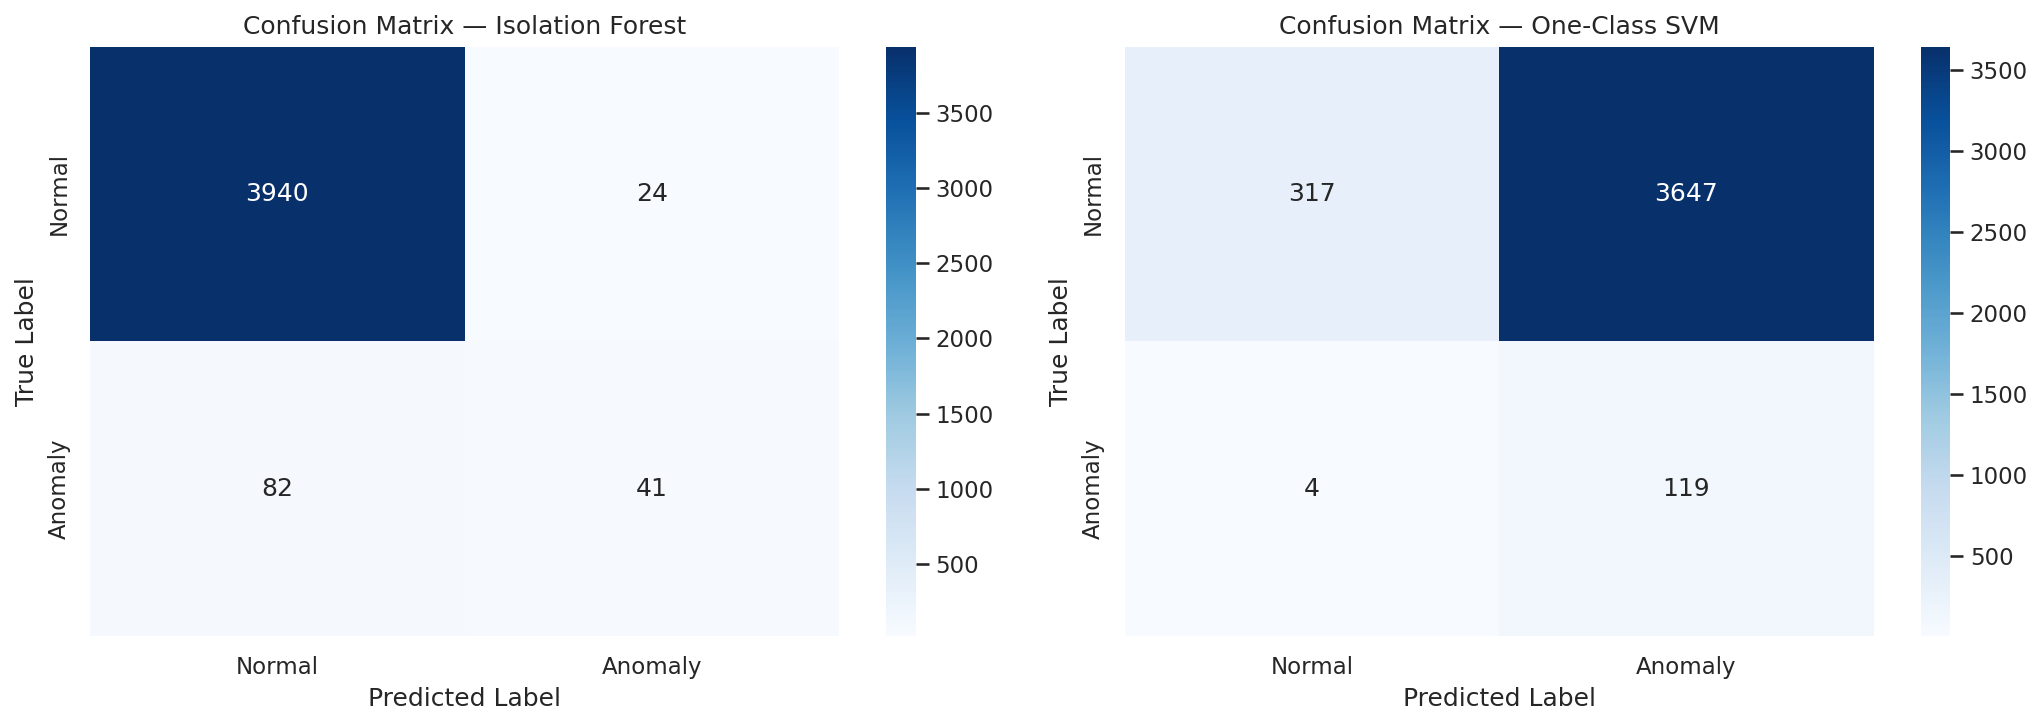

In [24]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(axes, [if_preds, svm_preds], ['Isolation Forest', 'One-Class SVM']):
    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}confusion_matrices.png')
plt.show()

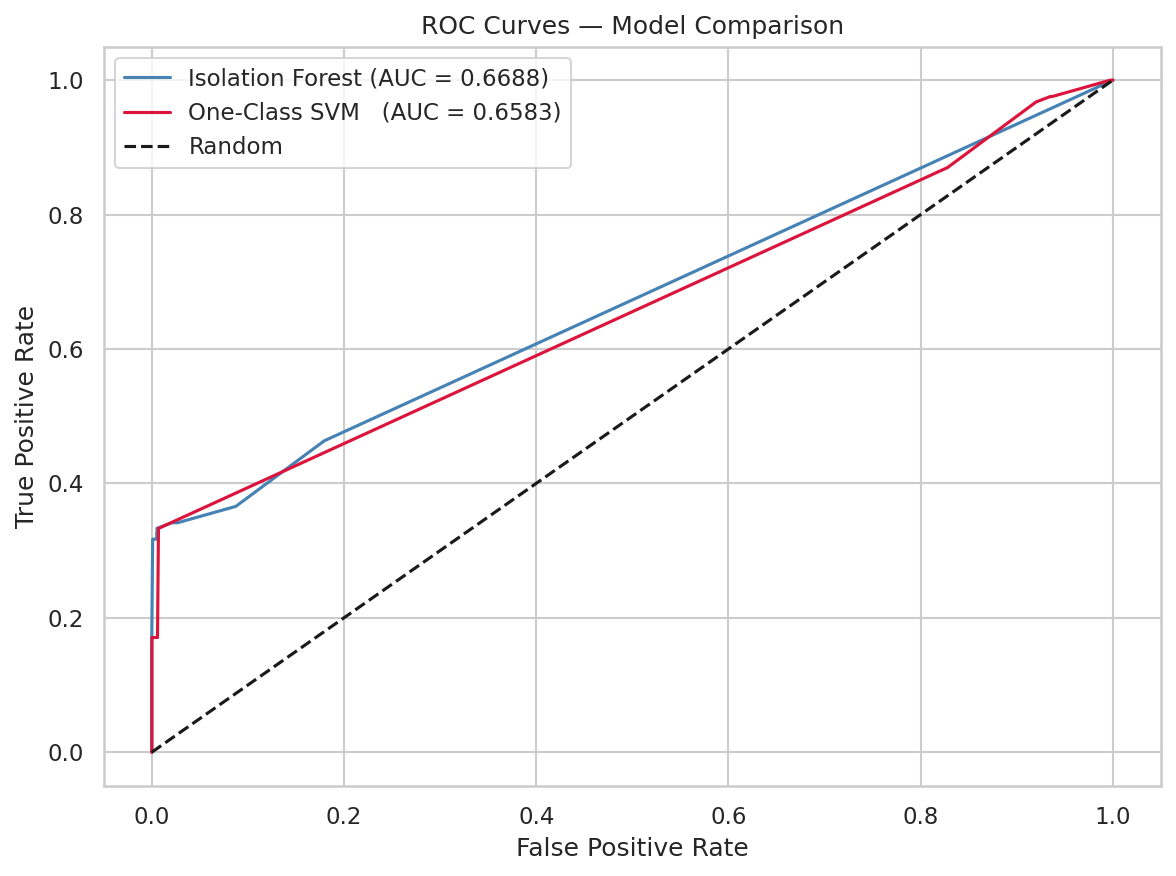

AUC Isolation Forest : 0.6688
AUC One-Class SVM    : 0.6583


In [25]:
# ROC curves
fpr_if,  tpr_if,  _ = roc_curve(y, -if_scores)
fpr_svm, tpr_svm, _ = roc_curve(y, -svm_scores)
auc_if  = auc(fpr_if,  tpr_if)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_if,  tpr_if,  label=f'Isolation Forest (AUC = {auc_if:.4f})',  color='steelblue')
plt.plot(fpr_svm, tpr_svm, label=f'One-Class SVM   (AUC = {auc_svm:.4f})',  color='crimson')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}roc_curves.png')
plt.show()

print(f'AUC Isolation Forest : {auc_if:.4f}')
print(f'AUC One-Class SVM    : {auc_svm:.4f}')

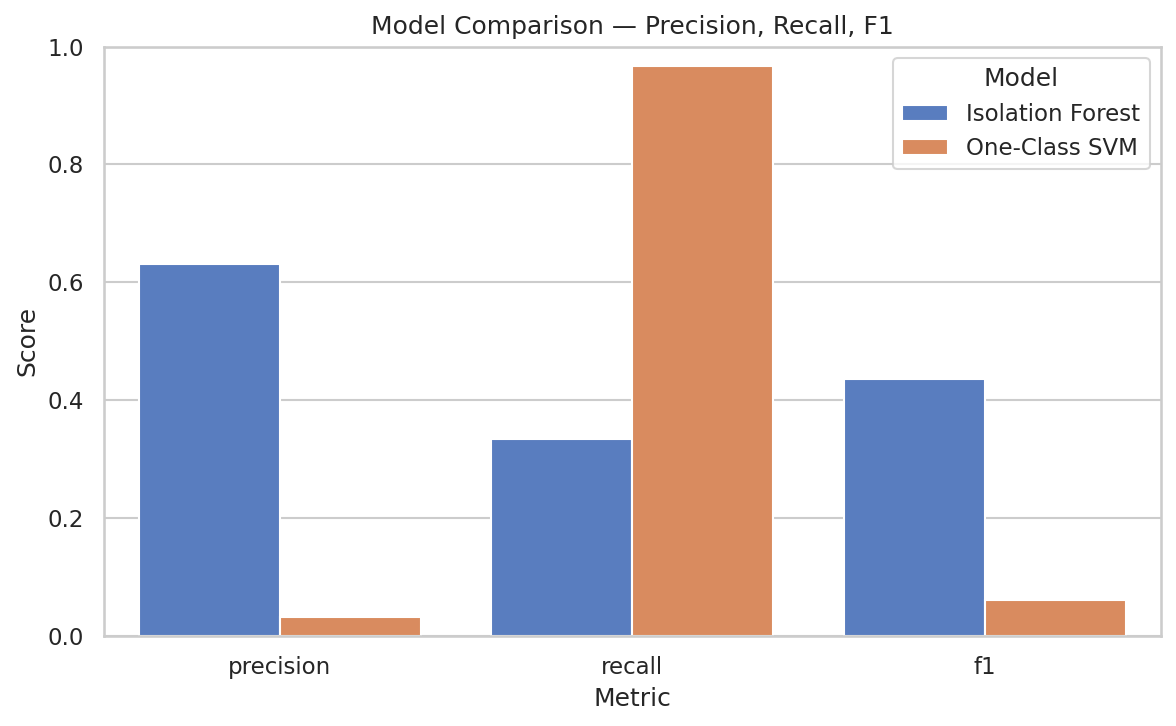

All evaluation complete.


In [26]:
# Metrics comparison
df_melted = results_df.melt(
    id_vars='model',
    value_vars=['precision', 'recall', 'f1'],
    var_name='metric',
    value_name='score'
)
plt.figure(figsize=(8, 5))
sns.barplot(data=df_melted, x='metric', y='score', hue='model')
plt.title('Model Comparison — Precision, Recall, F1')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Model')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}metrics_comparison.png')
plt.show()

print('All evaluation complete.')